In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("/content/sample_data/personal_finance_dataset_8000_extended.csv")
df.head()

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
1,2025-12-06,Transaction at Myntra,1919.05,Online Shopping,Net Banking,Hyderabad,Salary,Debit,Desktop,INR,Online Store,Yes,Saturday,December,Evening
2,2025-06-20,Transaction at BigBazaar,2837.68,Grocery,Debit Card,Bangalore,Savings,Debit,Mobile,INR,Retail,No,Friday,June,Evening
3,2025-04-23,Transaction at Property Tax Online,1071.04,Bills,Net Banking,Delhi,Current,Debit,POS Terminal,INR,Service,Yes,Wednesday,April,Afternoon
4,2025-03-06,Transaction at Asus Store,10722.80,Electronics,Debit Card,Mumbai,Current,Debit,Mobile,INR,Retail,Yes,Thursday,March,Evening


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df = df[df["TransactionType"] == "Debit"]
df["Amount"] = pd.to_numeric(df["Amount"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Date             8000 non-null   datetime64[ns]
 1   Description      8000 non-null   object        
 2   Amount           8000 non-null   float64       
 3   Category         8000 non-null   object        
 4   PaymentMethod    8000 non-null   object        
 5   Location         8000 non-null   object        
 6   AccountType      8000 non-null   object        
 7   TransactionType  8000 non-null   object        
 8   DeviceUsed       8000 non-null   object        
 9   Currency         8000 non-null   object        
 10  MerchantType     8000 non-null   object        
 11  LoyaltyProgram   8000 non-null   object        
 12  Weekday          8000 non-null   object        
 13  Month            8000 non-null   object        
 14  TimeOfDay        8000 non-null   object 

In [ ]:
total_expense = df["Amount"].sum()
average_expense = df["Amount"].mean()
median_expense = df["Amount"].median()
print("Total Expense: ", total_expense)
print("Average Expense:", average_expense)
print("Median Expense: ", median_expense)

Total Expense:  100415636.03
Average Expense: 12551.95450375
Median Expense:  3328.625


In [ ]:
category_expense = df.groupby("Category")["Amount"].sum()
print("Category-wise Expenses:")
print(category_expense)

Category-wise Expenses:
Category
Bills               2403511.15
Clothing            3265835.78
Electronics        61863867.55
Entertainment        459321.53
Food                 649145.95
Grocery             2036452.10
Healthcare          8586057.88
Online Shopping     8118349.93
Transport            818746.49
Travel             12214347.67
Name: Amount, dtype: float64


In [ ]:
high_expenses = df[df["Amount"] > average_expense]
high_expenses

,Date,Description,Amount,Category,PaymentMethod,Location,AccountType,TransactionType,DeviceUsed,Currency,MerchantType,LoyaltyProgram,Weekday,Month,TimeOfDay
0,2025-04-05,Transaction at IRCTC,20666.49,Travel,Debit Card,Kolkata,Salary,Debit,Mobile,INR,Service,No,Saturday,April,Night
13,2025-05-10,Transaction at IndiGo,24147.34,Travel,Net Banking,Hyderabad,Current,Debit,Mobile,INR,Service,No,Saturday,May,Evening
20,2025-11-10,Transaction at Nykaa,16470.71,Online Shopping,UPI,Bangalore,Savings,Debit,POS Terminal,INR,Online Store,No,Monday,November,Morning
22,2025-03-08,Transaction at AirAsia,20599.36,Travel,Debit Card,Mumbai,Salary,Debit,Mobile,INR,Service,No,Saturday,March,Evening
25,2025-05-29,Transaction at Apple Store,131786.69,Electronics,Net Banking,Pune,Current,Debit,Mobile,INR,Retail,No,Thursday,May,Evening
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7989,2025-05-15,Transaction at Dell Exclusive,78666.23,Electronics,Credit Card,Pune,Current,Debit,Desktop,INR,Retail,Yes,Thursday,May,Evening
7990,2025-04-15,Transaction at Samsung Store,121314.21,Electronics,Net Banking,Bangalore,Credit Card,Debit,POS Terminal,INR,Retail,Yes,Tuesday,April,Morning
7991,2025-06-27,Transaction at Aster,14584.50,Healthcare,Net Banking,Chennai,Credit Card,Debit,POS Terminal,INR,Service,No,Friday,June,Night
7992,2025-10-17,Transaction at Samsung Store,44792.89,Electronics,UPI,Mumbai,Salary,Debit,POS Terminal,INR,Retail,No,Friday,October,Evening


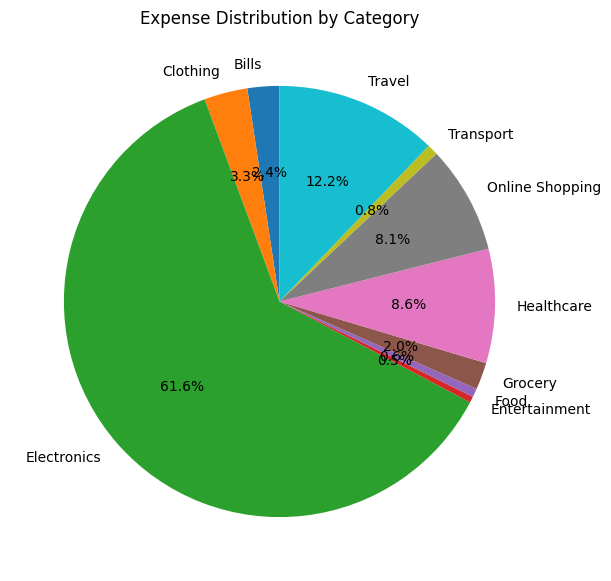

In [ ]:
plt.figure(figsize=(7,7))

category_expense.plot(
    kind="pie",
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Expense Distribution by Category")
plt.ylabel("")
plt.show()


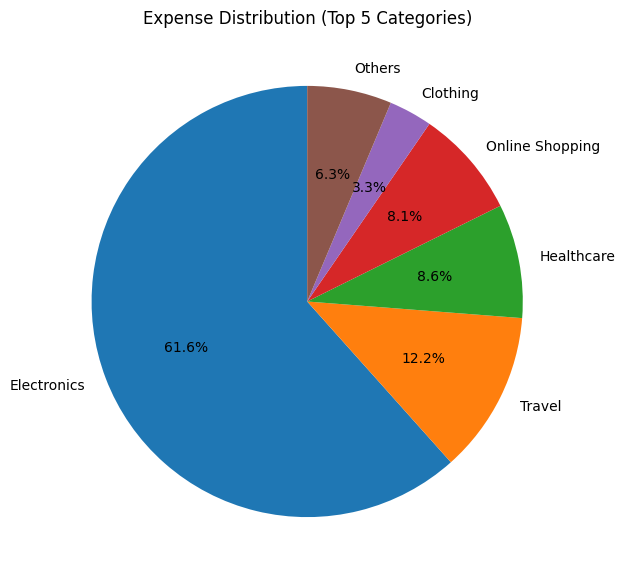

In [ ]:
top5 = category_expense.sort_values(ascending=False).head(5)
others = category_expense.sum() - top5.sum()
top5["Others"] = others

plt.figure(figsize=(7,7))
top5.plot(kind="pie", autopct="%1.1f%%", startangle=90)
plt.title("Expense Distribution (Top 5 Categories)")
plt.ylabel("")
plt.show()


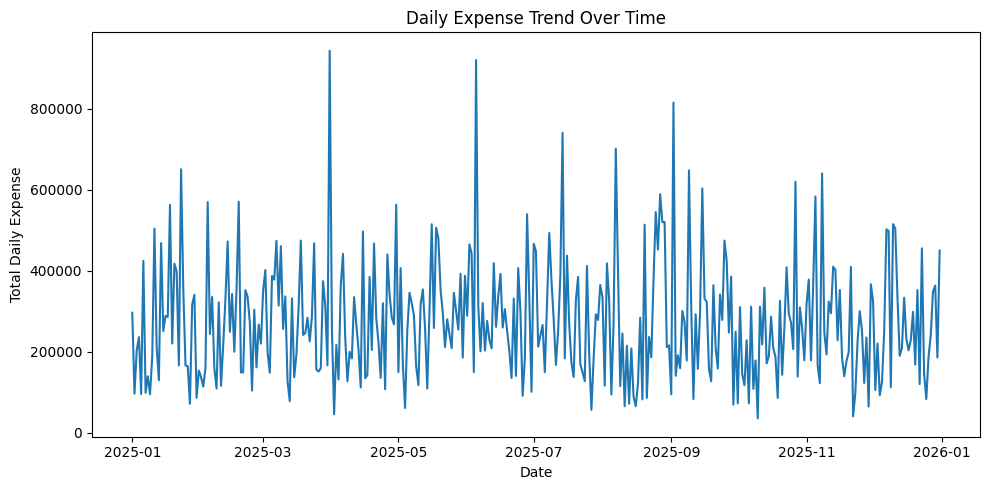

In [ ]:
daily_expense = df.resample("D", on="Date")["Amount"].sum()

plt.figure(figsize=(10,5))
plt.plot(daily_expense.index, daily_expense.values)

plt.title("Daily Expense Trend Over Time")
plt.xlabel("Date")
plt.ylabel("Total Daily Expense")
plt.tight_layout()
plt.show()


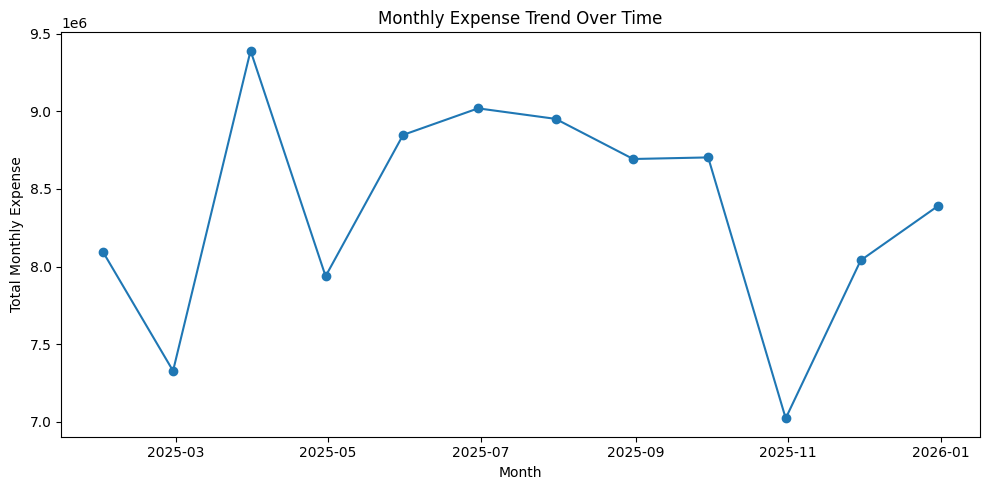

In [ ]:
monthly_expense = df.resample("ME", on="Date")["Amount"].sum()

plt.figure(figsize=(10,5))
plt.plot(monthly_expense.index, monthly_expense.values, marker="o")

plt.title("Monthly Expense Trend Over Time")
plt.xlabel("Month")
plt.ylabel("Total Monthly Expense")
plt.tight_layout()
plt.show()
